# Skin Disease Classification Using Deep Learning (HAM10000)

## Stage 1: Project Overview and Objectives


The main objectives of this project are:
- To analyze and prepare the HAM10000 skin lesion dataset for deep learning.
- To build a baseline Convolutional Neural Network (CNN) for skin disease classification.
- To improve model performance using Transfer Learning techniques.
- To apply advanced training strategies to enhance generalization.
- To evaluate the model using appropriate classification metrics.
- To test the model using Grad-CAM Visualisation technique.



## Stage 2: Dataset Description (HAM10000)


The HAM10000 dataset is a large collection of dermatoscopic images used for skin lesion
classification. It contains images belonging to multiple skin disease categories along
with a metadata file that provides labels for each image.


In [1]:
import pandas as pd


In [2]:
metadata_path = "../data/metadata/HAM10000_metadata.csv"
df = pd.read_csv(metadata_path)


In [3]:
df.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [4]:
df.tail()


,lesion_id,image_id,dx,dx_type,age,sex,localization
10010,HAM_0002867,ISIC_0033084,akiec,histo,40.0,male,abdomen
10011,HAM_0002867,ISIC_0033550,akiec,histo,40.0,male,abdomen
10012,HAM_0002867,ISIC_0033536,akiec,histo,40.0,male,abdomen
10013,HAM_0000239,ISIC_0032854,akiec,histo,80.0,male,face
10014,HAM_0003521,ISIC_0032258,mel,histo,70.0,female,back


In [5]:
df.shape


(10015, 7)

In [6]:
df.columns


Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


In [8]:
df.isnull().sum()


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [9]:
df['dx'].unique()


array(['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec'], dtype=object)

In [10]:
df['dx'].value_counts()


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [11]:
df['dx'].value_counts().to_frame(name='count')


,count
dx,
nv,6705
mel,1113
bkl,1099
bcc,514
akiec,327
vasc,142
df,115


## Stage 3: Exploratory Data Analysis (EDA)


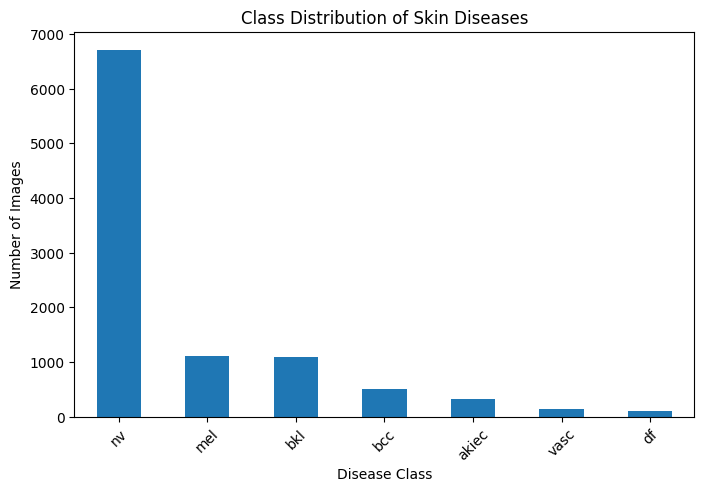

In [12]:
import matplotlib.pyplot as plt

class_counts = df['dx'].value_counts()

plt.figure(figsize=(8,5))
class_counts.plot(kind='bar')
plt.title("Class Distribution of Skin Diseases")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()


The dataset is highly imbalanced, with the nevus (nv) class dominating

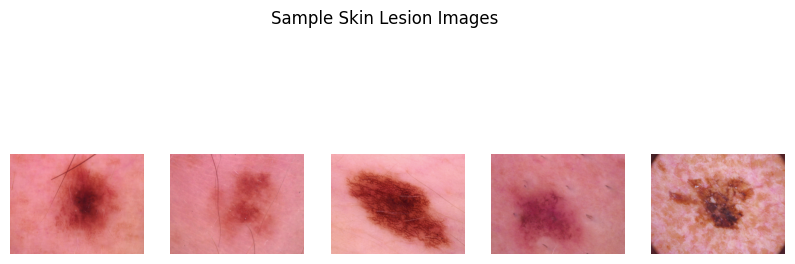

In [13]:
import os
from PIL import Image

# Path to image folders
img_dir_1 = "../data/images/HAM10000_images_part_1"
img_dir_2 = "../data/images/HAM10000_images_part_2"

# Get some image names
sample_images = os.listdir(img_dir_1)[:5]

plt.figure(figsize=(10,4))
for i, img_name in enumerate(sample_images):
    img_path = os.path.join(img_dir_1, img_name)
    img = Image.open(img_path)
    
    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.suptitle("Sample Skin Lesion Images")
plt.show()


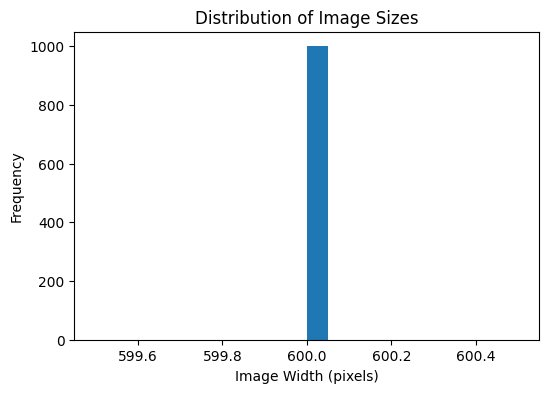

In [14]:
import numpy as np

image_sizes = []

for folder in [img_dir_1, img_dir_2]:
    for img_name in os.listdir(folder)[:500]:  # limit for speed
        img_path = os.path.join(folder, img_name)
        img = Image.open(img_path)
        image_sizes.append(img.size[0])  # width (or height)

plt.figure(figsize=(6,4))
plt.hist(image_sizes, bins=20)
plt.title("Distribution of Image Sizes")
plt.xlabel("Image Width (pixels)")
plt.ylabel("Frequency")
plt.show()


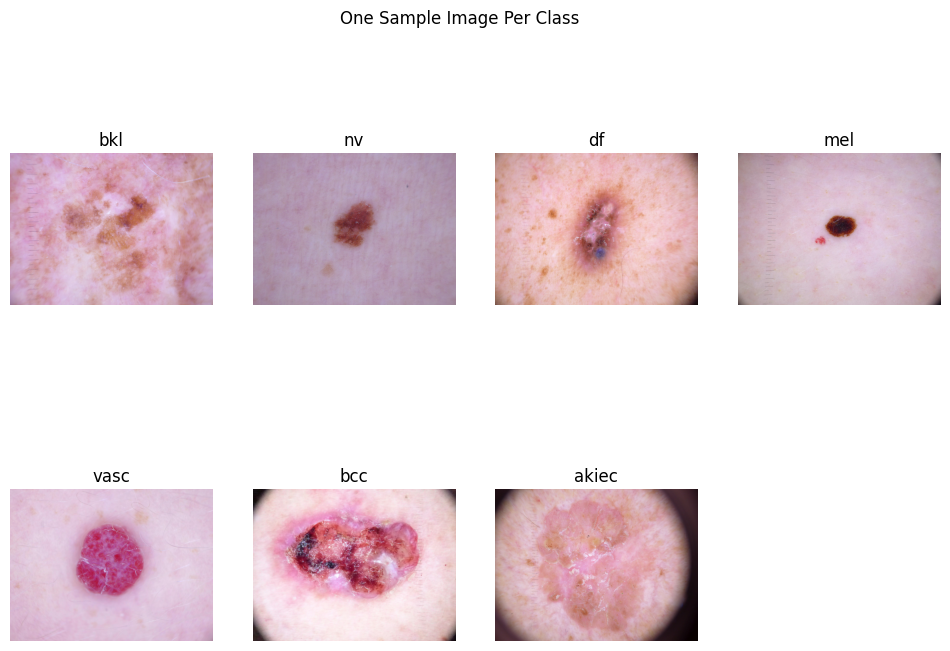

In [15]:
classes = df['dx'].unique()

plt.figure(figsize=(12,8))
for i, cls in enumerate(classes):
    img_id = df[df['dx'] == cls]['image_id'].iloc[0]
    
    img_path = os.path.join(img_dir_1, img_id + ".jpg")
    if not os.path.exists(img_path):
        img_path = os.path.join(img_dir_2, img_id + ".jpg")
    
    img = Image.open(img_path)
    
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')

plt.suptitle("One Sample Image Per Class")
plt.show()


Exploratory Data Analysis (EDA) was performed to understand the dataset distribution, identify class imbalance, and analyze image characteristics before model training.

## Stage 4: Data Preprocessing


In [16]:
import os

BASE_DIR = "../data/images"

train_dir = os.path.join(BASE_DIR, "train")
val_dir   = os.path.join(BASE_DIR, "val")

print("Train dir exists:", os.path.exists(train_dir))
print("Val dir exists:", os.path.exists(val_dir))


Train dir exists: True
Val dir exists: True


In [17]:
IMG_SIZE = (224, 224)   
BATCH_SIZE = 32        


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [19]:
train_datagen = ImageDataGenerator(
    rescale=1./255,             
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)


In [20]:
val_datagen = ImageDataGenerator(
    rescale=1./255
)


In [21]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)


Found 8012 images belonging to 7 classes.


In [22]:
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)


Found 2003 images belonging to 7 classes.


In [23]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight


In [24]:
labels = train_generator.classes
class_indices = train_generator.class_indices

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
class_weights



{0: np.float64(4.368593238822246),
 1: np.float64(2.7848453249913105),
 2: np.float64(1.3021290427433772),
 3: np.float64(12.440993788819876),
 4: np.float64(1.2860353130016051),
 5: np.float64(0.21338020666879728),
 6: np.float64(10.040100250626567)}

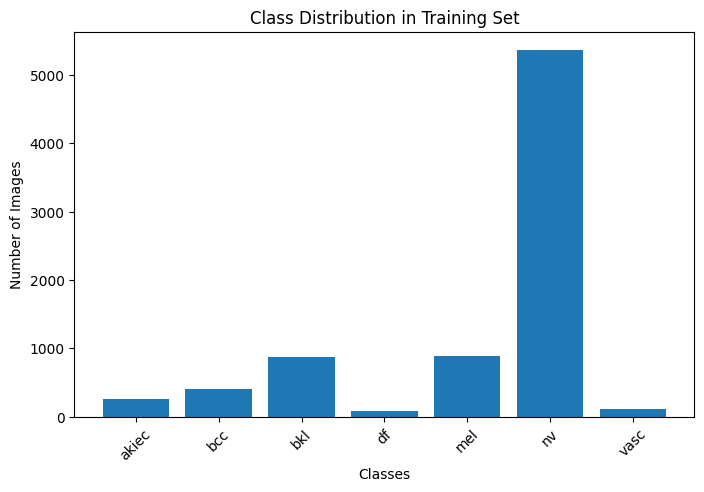

In [25]:
import matplotlib.pyplot as plt

class_names = list(class_indices.keys())
counts = np.bincount(labels)

plt.figure(figsize=(8,5))
plt.bar(class_names, counts)
plt.title("Class Distribution in Training Set")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()



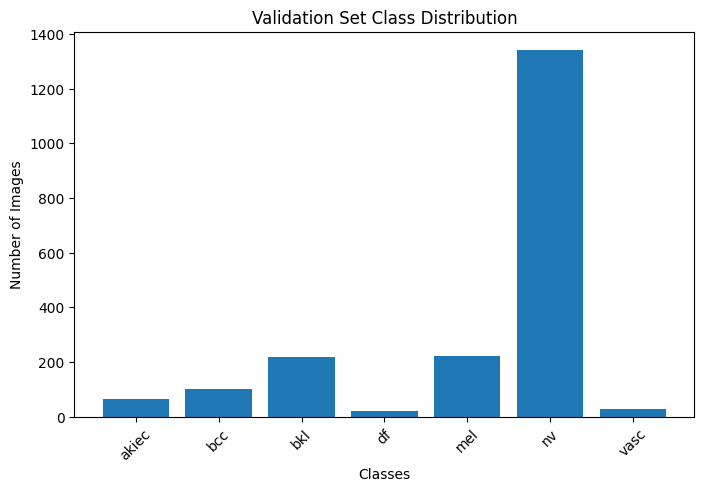

In [26]:

import matplotlib.pyplot as plt
import numpy as np


class_indices = val_generator.class_indices
class_names = list(class_indices.keys())


val_labels = val_generator.classes

counts = np.bincount(val_labels)

plt.figure(figsize=(8,5))
plt.bar(class_names, counts)
plt.title("Validation Set Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()


## Stage 5: Baseline CNN Model


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam



In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

baseline_cnn = Sequential([
    Input(shape=(224, 224, 3)),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])



In [29]:
baseline_cnn.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [30]:
history_cnn = baseline_cnn.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights
)


Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.4506 - loss: 1.8831 - val_accuracy: 0.5087 - val_loss: 1.2923
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 307s 1s/step - accuracy: 0.4207 - loss: 1.7180 - val_accuracy: 0.4319 - val_loss: 1.4758
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.4491 - loss: 1.5574 - val_accuracy: 0.4433 - val_loss: 1.3561
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.4376 - loss: 1.5051 - val_accuracy: 0.5012 - val_loss: 1.2046
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 285s 1s/step - accuracy: 0.4551 - loss: 1.4526 - val_accuracy: 0.3030 - val_loss: 1.7260
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 279s 1s/step - accuracy: 0.4596 - loss: 1.4078 - val_accuracy: 0.5362 - val_loss: 1.0607
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.4702 - loss: 1.3987 - val_accuracy: 0.4853 - val_loss: 1.2099
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 298s 1s/step - accuracy: 0.4783 - loss: 1.3377 - val_accu

## Stage 6: Baseline CNN Evaluation


In [39]:
import os

os.makedirs("../models", exist_ok=True)

baseline_cnn.save("../models/baseline_cnn_224.keras")




In [40]:
val_generator.reset()



In [41]:
import numpy as np


y_true = val_generator.classes


y_pred_probs = baseline_cnn.predict(val_generator, verbose=1)


y_pred = np.argmax(y_pred_probs, axis=1)


class_names = list(val_generator.class_indices.keys())


63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 321ms/step


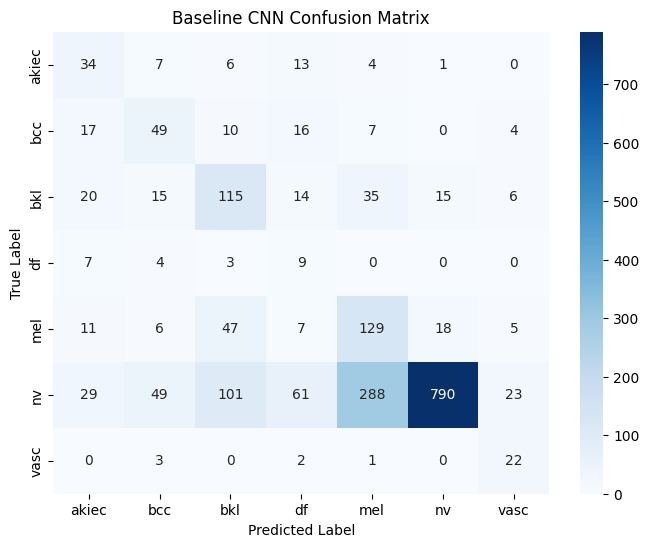

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Baseline CNN Confusion Matrix")
plt.show()


In [43]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)


              precision    recall  f1-score   support

       akiec       0.29      0.52      0.37        65
         bcc       0.37      0.48      0.42       103
         bkl       0.41      0.52      0.46       220
          df       0.07      0.39      0.12        23
         mel       0.28      0.58      0.38       223
          nv       0.96      0.59      0.73      1341
        vasc       0.37      0.79      0.50        28

    accuracy                           0.57      2003
   macro avg       0.39      0.55      0.42      2003
weighted avg       0.75      0.57      0.62      2003



In [44]:
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

metrics_df = pd.DataFrame({
    "Class": class_names,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1
})

metrics_df


,Class,Precision,Recall,F1-Score
0,akiec,0.288136,0.523077,0.371585
1,bcc,0.368421,0.475728,0.415254
2,bkl,0.407801,0.522727,0.458167
3,df,0.073770,0.391304,0.124138
4,mel,0.278017,0.578475,0.375546
5,nv,0.958738,0.589113,0.729792
6,vasc,0.366667,0.785714,0.500000


In [56]:
baseline_acc = [
    0.4506, 0.4207, 0.4491, 0.4376, 0.4551,
    0.4596, 0.4702, 0.4783, 0.4973, 0.4978,
    0.5105, 0.5009, 0.5059,0.5168,
]

baseline_val_acc = [
    0.5087, 0.4319, 0.4433, 0.5012, 0.3030,
    0.5362, 0.4853, 0.5377, 0.4938, 0.5312,
    0.5492, 0.4783, 0.4998, 0.5397
]

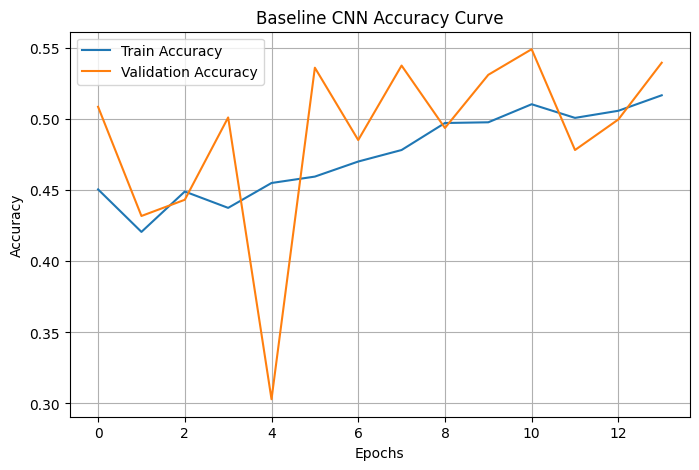

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(baseline_acc, label='Train Accuracy')
plt.plot(baseline_val_acc, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Baseline CNN Accuracy Curve')
plt.legend()
plt.grid(True)
plt.show()


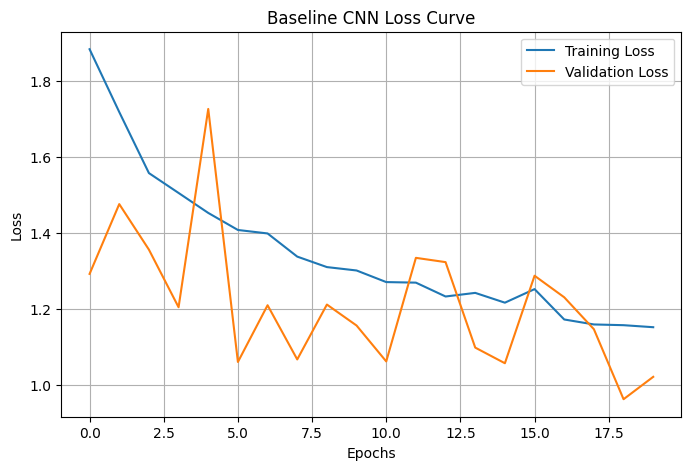

In [47]:
plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Baseline CNN Loss Curve')
plt.legend()
plt.grid(True)
plt.show()


## Stage 7: Transfer Learning Using EfficientNet-B2 (Final Model)


In [27]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint





In [28]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)



In [29]:
BATCH_SIZE = 16  

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)




Found 8012 images belonging to 7 classes.
Found 2003 images belonging to 7 classes.


In [31]:
base_model = EfficientNetB2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  





In [32]:

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.5)(x)
outputs = Dense(train_generator.num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)


In [33]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [43]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        "../models/effnet_b2_stage1_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    )
]



In [35]:
history_b2_stage1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)




Epoch 1/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 903ms/step - accuracy: 0.2619 - loss: 1.9151
Epoch 1: val_accuracy improved from None to 0.57414, saving model to ../models/effnet_b2_stage1_best.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 569s 1s/step - accuracy: 0.3466 - loss: 1.7205 - val_accuracy: 0.5741 - val_loss: 1.2756 - learning_rate: 1.0000e-04
Epoch 2/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 887ms/step - accuracy: 0.4714 - loss: 1.4157
Epoch 2: val_accuracy did not improve from 0.57414
501/501 ━━━━━━━━━━━━━━━━━━━━ 518s 1s/step - accuracy: 0.4889 - loss: 1.3573 - val_accuracy: 0.5032 - val_loss: 1.2643 - learning_rate: 1.0000e-04
Epoch 3/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.5141 - loss: 1.2383
Epoch 3: val_accuracy did not improve from 0.57414
501/501 ━━━━━━━━━━━━━━━━━━━━ 425s 848ms/step - accuracy: 0.5235 - loss: 1.2471 - val_accuracy: 0.5437 - val_loss: 1.1954 - learning_rate: 1.0000e-04
Epoch 4/10
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 670ms/step - accuracy: 0.5588 - loss: 1.110

In [36]:
from tensorflow.keras.models import load_model

model = load_model("../models/effnet_b2_stage1_best.keras")


In [38]:
for layer in model.layers[-40:]:
    layer.trainable = True



In [42]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)



In [44]:
history_b2_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)



Epoch 1/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5327 - loss: 1.1496
Epoch 1: val_accuracy improved from None to 0.62207, saving model to ../models/effnet_b2_stage1_best.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 964s 2s/step - accuracy: 0.5609 - loss: 1.0939 - val_accuracy: 0.6221 - val_loss: 1.0077 - learning_rate: 3.0000e-05
Epoch 2/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.6003 - loss: 0.9563
Epoch 2: val_accuracy improved from 0.62207 to 0.63105, saving model to ../models/effnet_b2_stage1_best.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 455s 908ms/step - accuracy: 0.6047 - loss: 0.9422 - val_accuracy: 0.6311 - val_loss: 0.9724 - learning_rate: 3.0000e-05
Epoch 3/15
501/501 ━━━━━━━━━━━━━━━━━━━━ 0s 782ms/step - accuracy: 0.6129 - loss: 0.9165
Epoch 3: val_accuracy improved from 0.63105 to 0.67000, saving model to ../models/effnet_b2_stage1_best.keras
501/501 ━━━━━━━━━━━━━━━━━━━━ 455s 907ms/step - accuracy: 0.6157 - loss: 0.8868 - val_accuracy: 0.6700 - val_loss: 0.8

## Stage 8: EfficientNet B2 Evaluation

In [46]:
from tensorflow.keras.models import load_model

model = load_model("../models/effnet_b2_stage1_best.keras")


In [47]:
import numpy as np

val_generator.reset()

y_true = val_generator.classes
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(val_generator.class_indices.keys())


126/126 ━━━━━━━━━━━━━━━━━━━━ 90s 656ms/step


In [48]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))


              precision    recall  f1-score   support

       akiec     0.6154    0.4923    0.5470        65
         bcc     0.6231    0.7864    0.6953       103
         bkl     0.5122    0.7636    0.6131       220
          df     0.3220    0.8261    0.4634        23
         mel     0.3834    0.6413    0.4799       223
          nv     0.9696    0.7383    0.8383      1341
        vasc     0.6000    0.8571    0.7059        28

    accuracy                         0.7274      2003
   macro avg     0.5751    0.7293    0.6204      2003
weighted avg     0.8122    0.7274    0.7507      2003



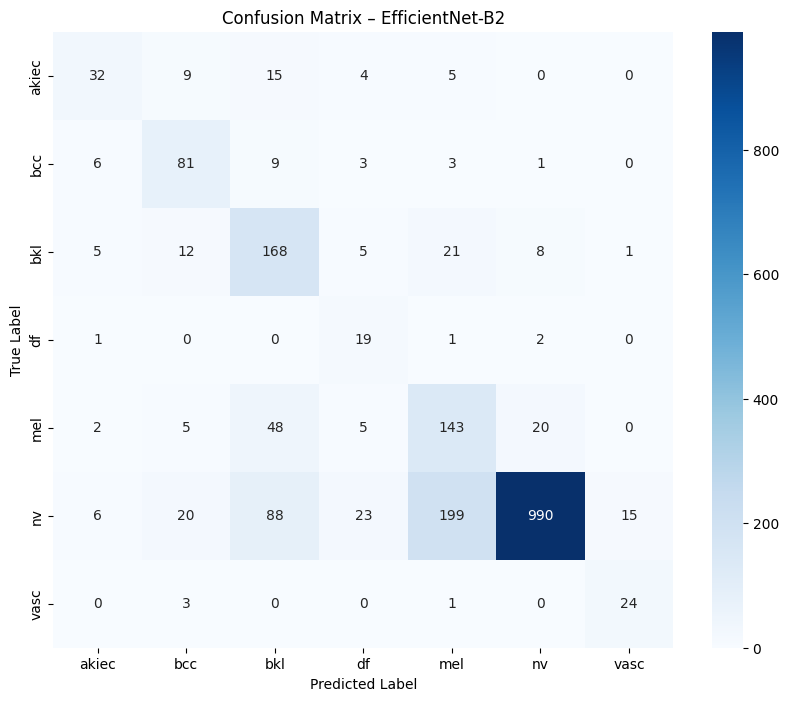

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – EfficientNet-B2")
plt.show()


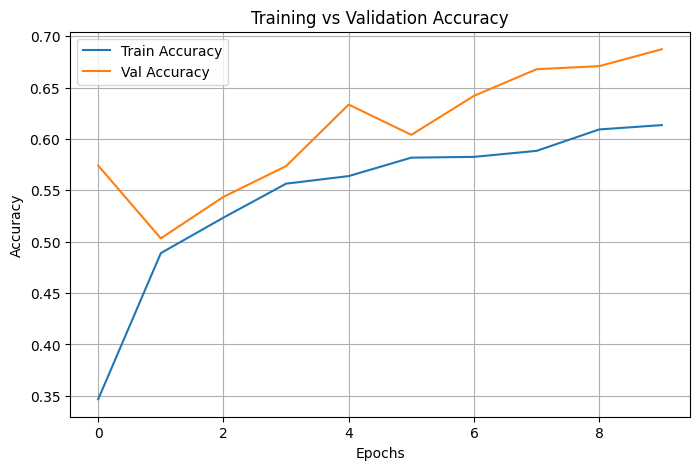

In [50]:
plt.figure(figsize=(8,5))
plt.plot(history_b2_stage1.history['accuracy'], label='Train Accuracy')
plt.plot(history_b2_stage1.history['val_accuracy'], label='Val Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


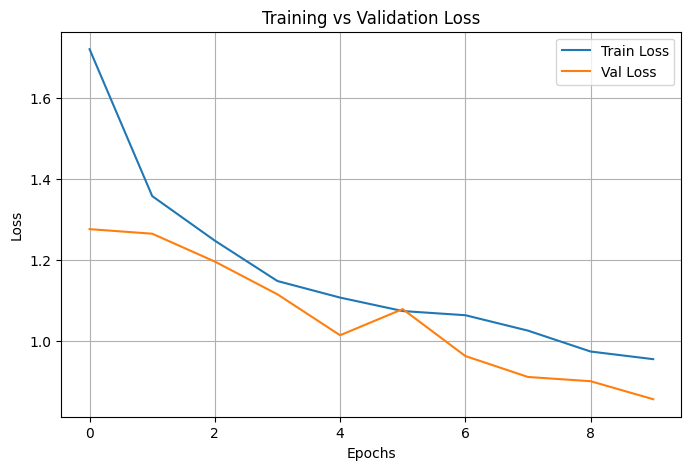

In [51]:
plt.figure(figsize=(8,5))
plt.plot(history_b2_stage1.history['loss'], label='Train Loss')
plt.plot(history_b2_stage1.history['val_loss'], label='Val Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## Stage 9: Grad-CAM Visualisation

Grad-CAM visualization was used to highlight the regions of the skin image that most influenced the model’s prediction, improving interpretability and trust in the model.

In [59]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model


In [60]:
model = load_model("../models/effnet_b2_stage1_best.keras")


In [61]:
last_conv_layer_name = "top_conv"


In [62]:
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_1     │ (None, 224, 224,  │          7 │ rescaling_2[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_3         │ (None, 224, 224,  │          0 │ normalization_1[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_3[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 16,932,072 (64.59 MB)

 Trainable params: 4,219,251 (16.10 MB)

 Non-trainable params: 4,274,317 (16.31 MB)

 Optimizer params: 8,438,504 (32.19 MB)

In [63]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [64]:
def load_image(img_path, img_size=(224,224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=img_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    return img, img_array


In [65]:
def save_and_display_gradcam(img, heatmap, alpha=0.4):
    img = np.array(img)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed_img = heatmap * alpha + img
    superimposed_img = np.uint8(superimposed_img)

    plt.figure(figsize=(6,6))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title("Grad-CAM Visualization")
    plt.show()


In [67]:
from tensorflow.keras.models import load_model
model = load_model("../models/effnet_b2_stage1_best.keras")


In [68]:
class_names = list(train_generator.class_indices.keys())
print(class_names)


['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [69]:
img_path = "../data/images/test/ISIC_0029306.jpg"  

img, img_array = load_image(img_path)


In [71]:
preds = model.predict(img_array)
pred_class_idx = np.argmax(preds)
pred_class = class_names[pred_class_idx]
confidence = preds[0][pred_class_idx]

print(f"Predicted Disease: {pred_class}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted Disease: vasc


In [72]:
last_conv_layer_name = "top_conv"  # Correct for EfficientNet-B2

heatmap = make_gradcam_heatmap(
    img_array,
    model,
    last_conv_layer_name
)


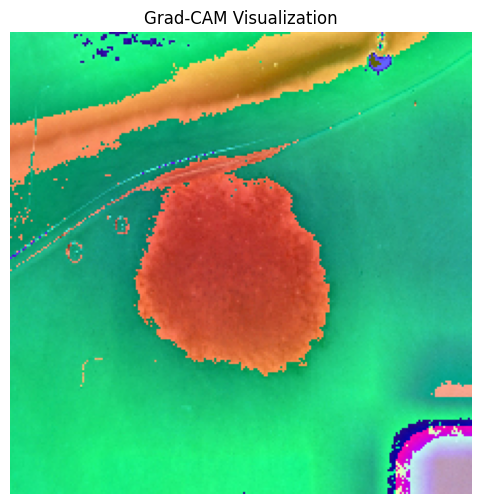

In [73]:
save_and_display_gradcam(img, heatmap)


The trained model was used to predict the skin disease from a given test image for each class.